# Sentiment Analysis using DistilBERT

## Project Overview
This project demonstrates the deployment of a pre-trained Language Model (DistilBERT) for sentiment analysis on movie reviews from the IMDB dataset.

### Objectives
- Load and explore the IMDB dataset
- Use a pre-trained DistilBERT model
- Perform sentiment prediction
- Evaluate model performance
- Visualize results
- Analyze strengths and limitations of transformer models

In [1]:
# Install Required Libraries

!pip install transformers datasets scikit-learn matplotlib seaborn torch --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Required Libraries

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load IMDB Dataset

The IMDB dataset contains movie reviews labeled as:

- Positive (1)
- Negative (0)

For faster execution, only a subset is used.

In [3]:
dataset = load_dataset("imdb")

train_data = dataset["train"].shuffle(seed=42).select(range(1000))
test_data = dataset["test"].shuffle(seed=42).select(range(300))

print("Training Samples:", len(train_data))
print("Testing Samples:", len(test_data))

print("\nSample Review:")
print(train_data[0])

Training Samples: 1000
Testing Samples: 300

Sample Review:
{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...', 'label': 1}


## Load Pre-trained DistilBERT Model

We use a sentiment-analysis pipeline built on DistilBERT.

In [4]:
nlp_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("Model Loaded Successfully")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model Loaded Successfully


## Generate Predictions

The model predicts whether each review is positive or negative.

In [ ]:
def predict(text):
    result = nlp_model(text[:512])[0]
    return 1 if result["label"] == "POSITIVE" else 0


y_true = []
y_pred = []

for sample in test_data:
    y_true.append(sample["label"])
    y_pred.append(predict(sample["text"]))

print("Prediction Completed")

Prediction Completed


## Model Evaluation

Evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-Score

In [ ]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    zero_division=0
))

Accuracy: 0.8033333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       150
           1       0.80      0.81      0.80       150

    accuracy                           0.80       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.80      0.80       300



## Confusion Matrix

A confusion matrix helps visualize correct and incorrect predictions.

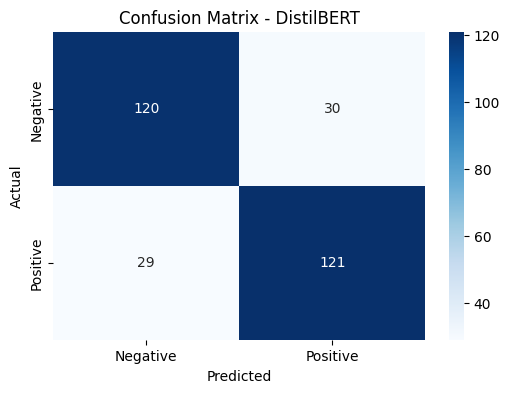

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT")

plt.show()

## Testing Custom Sentences

Let's see how the model performs on unseen text.

In [ ]:
examples = [
    "This movie was absolutely fantastic and inspiring!",
    "Worst film I have ever seen, boring and slow.",
    "The plot was okay but the acting was average.",
    "I love how realistic and emotional this story is."
]

for text in examples:
    print("Review:", text)
    print("Prediction:", nlp_model(text)[0])
    print("-"*60)

Review: This movie was absolutely fantastic and inspiring!
Prediction: {'label': 'POSITIVE', 'score': 0.9998886585235596}
------------------------------------------------------------
Review: Worst film I have ever seen, boring and slow.
Prediction: {'label': 'NEGATIVE', 'score': 0.9998157620429993}
------------------------------------------------------------
Review: The plot was okay but the acting was average.
Prediction: {'label': 'NEGATIVE', 'score': 0.928252100944519}
------------------------------------------------------------
Review: I love how realistic and emotional this story is.
Prediction: {'label': 'POSITIVE', 'score': 0.9998781681060791}
------------------------------------------------------------


## Predicted Label Distribution

This chart shows the number of positive and negative predictions.

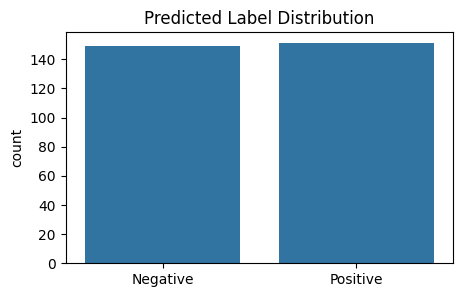

In [ ]:
plt.figure(figsize=(5,3))

sns.countplot(x=y_pred)

plt.xticks(
    [0,1],
    ["Negative","Positive"]
)

plt.title("Predicted Label Distribution")

plt.show()

## Research Questions

1. How well does DistilBERT understand contextual sentiment?
2. How does it handle ambiguous reviews?
3. Does text truncation affect performance?
4. How does it compare with traditional ML models?
5. What types of reviews cause misclassification?

In [ ]:
research_questions = """
1. How well does DistilBERT understand contextual sentiment in ambiguous sentences?

2. Does the model perform better on clearly positive/negative text than neutral text?

3. How does truncation of long text affect prediction accuracy?

4. Can transformer-based models generalize better than traditional ML models?

5. What types of sentences cause misclassification?
"""

print(research_questions)


1. How well does DistilBERT understand contextual sentiment in ambiguous sentences?

2. Does the model perform better on clearly positive/negative text than neutral text?

3. How does truncation of long text affect prediction accuracy?

4. Can transformer-based models generalize better than traditional ML models?

5. What types of sentences cause misclassification?



## Conclusion

In [ ]:
conclusion = """
✔ DistilBERT demonstrates strong performance in sentiment analysis.

✔ The model effectively captures contextual meaning.

✔ It performs best on clearly positive or negative reviews.

✔ Challenges remain with:
   - Sarcasm
   - Neutral sentiment
   - Mixed emotions

✔ Transformer models generally outperform traditional ML techniques.

Future Improvements:
- Fine-tune on custom datasets
- Use RoBERTa or BERT-Large
- Improve handling of long documents
"""

print(conclusion)


✔ DistilBERT demonstrates strong performance in sentiment analysis.

✔ The model effectively captures contextual meaning.

✔ It performs best on clearly positive or negative reviews.

✔ Challenges remain with:
   - Sarcasm
   - Neutral sentiment
   - Mixed emotions

✔ Transformer models generally outperform traditional ML techniques.

Future Improvements:
- Fine-tune on custom datasets
- Use RoBERTa or BERT-Large
- Improve handling of long documents

